<a href="https://colab.research.google.com/github/anamaria29/tarea3_compparalela_anam/blob/main/analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio:
## *"NYC Taxi Trip Duration"*

### Librerías:

In [ ]:
!pip install polars matplotlib seaborn numpy

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

### Cargar Dataset:

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving NYC.csv to NYC.csv


In [ ]:
filename = list(uploaded.keys())[0]

df = pl.read_csv(filename)

print("Dataset cargado correctamente")
print("Dimensiones:", df.shape)

df.head()

Dataset cargado correctamente
Dimensiones: (1458644, 11)


id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,i64,str,str,i64,f64,f64,f64,f64,str,i64
"""id2875421""",2,"""2016-03-14 17:24:55""","""2016-03-14 17:32:30""",1,-73.982155,40.767937,-73.96463,40.765602,"""N""",455
"""id2377394""",1,"""2016-06-12 00:43:35""","""2016-06-12 00:54:38""",1,-73.980415,40.738564,-73.999481,40.731152,"""N""",663
"""id3858529""",2,"""2016-01-19 11:35:24""","""2016-01-19 12:10:48""",1,-73.979027,40.763939,-74.005333,40.710087,"""N""",2124
"""id3504673""",2,"""2016-04-06 19:32:31""","""2016-04-06 19:39:40""",1,-74.01004,40.719971,-74.012268,40.706718,"""N""",429
"""id2181028""",2,"""2016-03-26 13:30:55""","""2016-03-26 13:38:10""",1,-73.973053,40.793209,-73.972923,40.78252,"""N""",435


### Inspección del Dataset:

Información General:

In [ ]:
print("\nColumnas:")
print(df.columns)

print("\nTipos de datos:")
print(df.schema)


Columnas:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']

Tipos de datos:
Schema({'id': String, 'vendor_id': Int64, 'pickup_datetime': String, 'dropoff_datetime': String, 'passenger_count': Int64, 'pickup_longitude': Float64, 'pickup_latitude': Float64, 'dropoff_longitude': Float64, 'dropoff_latitude': Float64, 'store_and_fwd_flag': String, 'trip_duration': Int64})


Tabla de Variables:

In [ ]:
variables = pl.DataFrame({
    "Variable": df.columns,
    "Tipo": [
        str(df.schema[col])
        for col in df.columns
    ]
})

variables

Variable,Tipo
str,str
"""id""","""String"""
"""vendor_id""","""Int64"""
"""pickup_datetime""","""String"""
"""dropoff_datetime""","""String"""
"""passenger_count""","""Int64"""
…,…
"""pickup_latitude""","""Float64"""
"""dropoff_longitude""","""Float64"""
"""dropoff_latitude""","""Float64"""


Estadísticas Descriptivas:

In [ ]:
stats = df.describe()

stats

statistic,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,str,f64,str,str,f64,f64,f64,f64,f64,str,f64
"""count""","""1458644""",1.458644e6,"""1458644""","""1458644""",1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6,"""1458644""",1.458644e6
"""null_count""","""0""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0
"""mean""",null,1.53495,null,null,1.66453,-73.973486,40.750921,-73.973416,40.7518,null,959.492273
"""std""",null,0.498777,null,null,1.314242,0.070902,0.032881,0.070643,0.035891,null,5237.431724
"""min""","""id0000001""",1.0,"""2016-01-01 00:00:17""","""2016-01-01 00:03:31""",0.0,-121.933342,34.359695,-121.933304,32.181141,"""N""",1.0
"""25%""",null,1.0,null,null,1.0,-73.991867,40.737347,-73.991325,40.735886,null,397.0
"""50%""",null,2.0,null,null,1.0,-73.981743,40.754101,-73.979752,40.754524,null,662.0
"""75%""",null,2.0,null,null,2.0,-73.967331,40.76836,-73.963013,40.76981,null,1075.0
"""max""","""id4000000""",2.0,"""2016-06-30 23:59:39""","""2016-07-01 23:02:03""",9.0,-61.335529,51.881084,-61.335529,43.921028,"""Y""",3.526282e6


Estadísticas Numéricas:

In [ ]:
numeric = df.select(
    pl.col(
        pl.NUMERIC_DTYPES
    )
)

numeric.describe()

statistic,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
str,f64,f64,f64,f64,f64,f64,f64
"""count""",1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6,1.458644e6
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.53495,1.66453,-73.973486,40.750921,-73.973416,40.7518,959.492273
"""std""",0.498777,1.314242,0.070902,0.032881,0.070643,0.035891,5237.431724
"""min""",1.0,0.0,-121.933342,34.359695,-121.933304,32.181141,1.0
"""25%""",1.0,1.0,-73.991867,40.737347,-73.991325,40.735886,397.0
"""50%""",2.0,1.0,-73.981743,40.754101,-73.979752,40.754524,662.0
"""75%""",2.0,2.0,-73.967331,40.76836,-73.963013,40.76981,1075.0
"""max""",2.0,9.0,-61.335529,51.881084,-61.335529,43.921028,3.526282e6


Valores Faltantes:

In [ ]:
missing = df.null_count()

missing

id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0


In [ ]:
total = len(df)

missing_summary = []

for col in df.columns:

    nulls = df[col].null_count()

    pct = (
        nulls
        /
        total
    ) * 100

    missing_summary.append([
        col,
        nulls,
        round(
            pct,
            2
        )
    ])

missing_df = pl.DataFrame(
    missing_summary,
    schema=[
        "Variable",
        "Valores faltantes",
        "%"
    ]
)

missing_df.sort(
    "%",
    descending=True
)

Variable,Valores faltantes,%
str,i64,f64
"""id""",0,0.0
"""vendor_id""",0,0.0
"""pickup_datetime""",0,0.0
"""dropoff_datetime""",0,0.0
"""passenger_count""",0,0.0
…,…,…
"""pickup_latitude""",0,0.0
"""dropoff_longitude""",0,0.0
"""dropoff_latitude""",0,0.0


Análisis de Variable Objetivo:

In [ ]:
target = "trip_duration"

df.select(
    target
).describe()

statistic,trip_duration
str,f64
"""count""",1.458644e6
"""null_count""",0.0
"""mean""",959.492273
"""std""",5237.431724
"""min""",1.0
"""25%""",397.0
"""50%""",662.0
"""75%""",1075.0
"""max""",3.526282e6


Distribución de la Variable Objetivo:

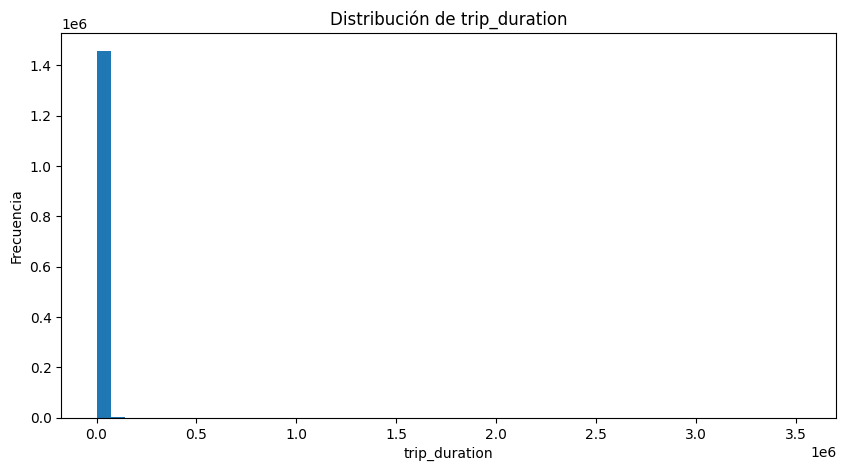

In [ ]:
plt.figure(
    figsize=(10,5)
)

plt.hist(
    df[target],
    bins=50
)

plt.title(
    f"Distribución de {target}"
)

plt.xlabel(target)

plt.ylabel("Frecuencia")

plt.show()

Distribución de Variables Numéricas:

In [ ]:
numeric_cols = [
    c
    for c
    in df.columns

    if df[c].dtype
    in pl.NUMERIC_DTYPES
]

numeric_cols

['vendor_id',
 'passenger_count',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'trip_duration']

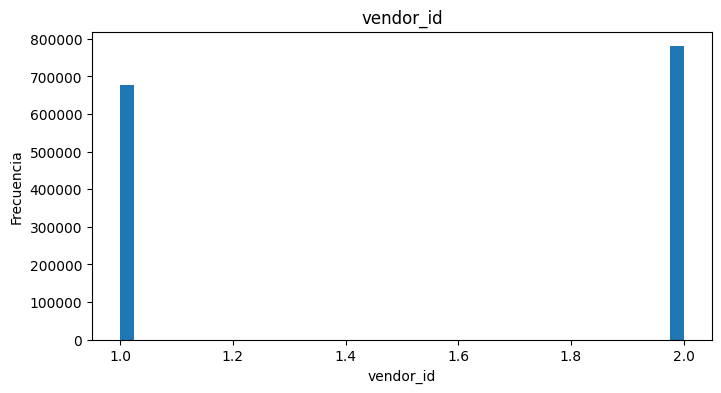

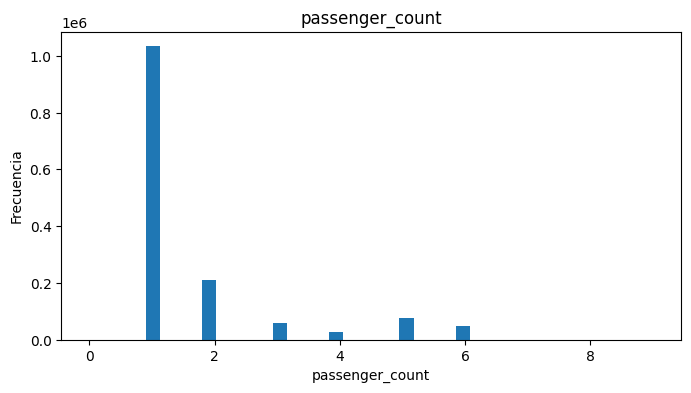

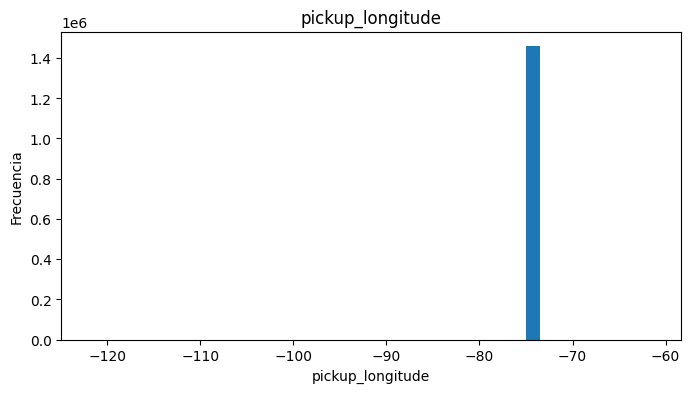

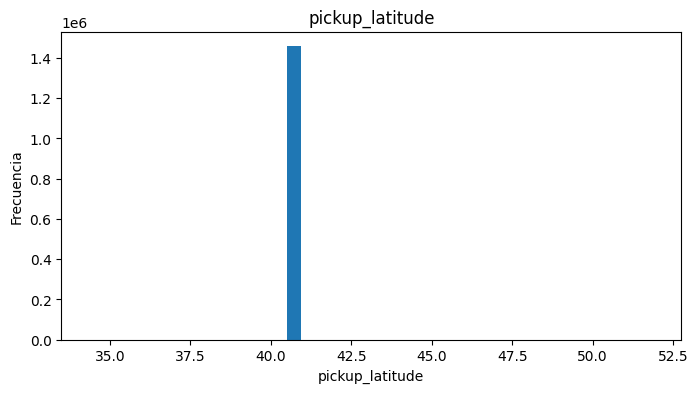

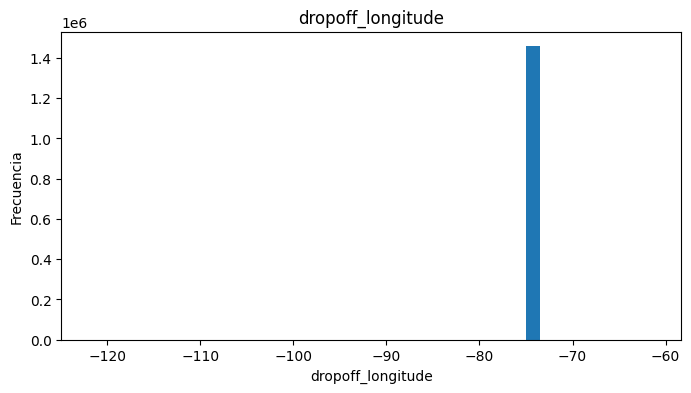

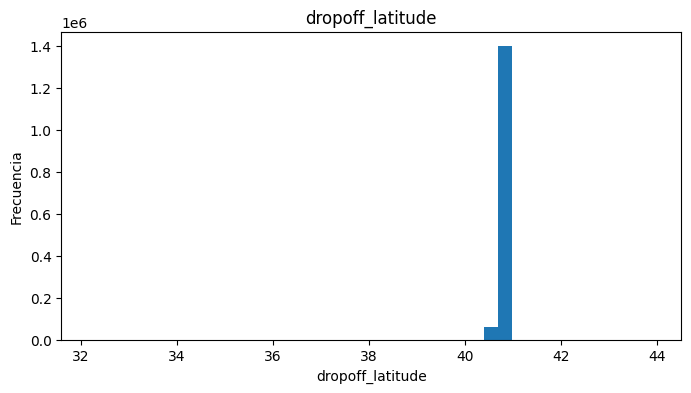

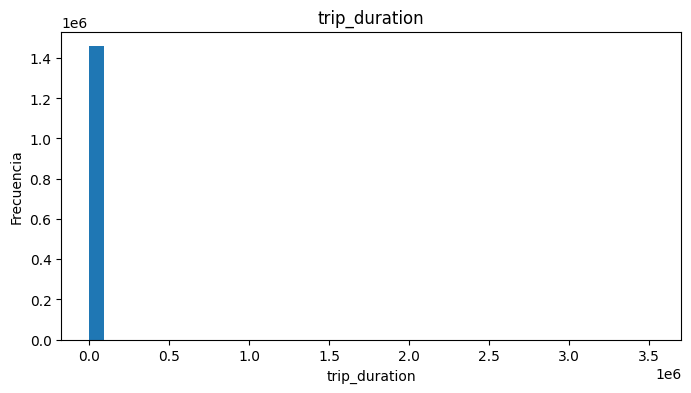

In [ ]:
for col in numeric_cols:

    plt.figure(
        figsize=(8,4)
    )

    plt.hist(
        df[col],
        bins=40
    )

    plt.title(
        col
    )

    plt.xlabel(
        col
    )

    plt.ylabel(
        "Frecuencia"
    )

    plt.show()

Distribución de Variables Categóricas:

In [ ]:
categorical = [
    c
    for c
    in df.columns

    if (
        df[c].dtype
        ==
        pl.String
    )
]

categorical

['id', 'pickup_datetime', 'dropoff_datetime', 'store_and_fwd_flag']

In [ ]:
for col in categorical:

    print(f"\nVariable: {col}")

    display(

        df
        .group_by(
            col
        )
        .len()
        .sort(
            "len",
            descending=True
        )
        .head(10)

    )


Variable: id


id,len
str,u32
"""id3962970""",1
"""id0425264""",1
"""id1582257""",1
"""id3259944""",1
"""id2850523""",1
"""id2979883""",1
"""id0628800""",1
"""id2953084""",1
"""id0147842""",1



Variable: pickup_datetime


pickup_datetime,len
str,u32
"""2016-06-10 23:17:17""",5
"""2016-04-05 18:55:21""",5
"""2016-02-09 21:03:38""",5
"""2016-01-12 18:48:44""",5
"""2016-05-07 13:18:07""",5
"""2016-03-04 08:07:34""",5
"""2016-02-24 20:22:47""",4
"""2016-05-15 15:57:58""",4
"""2016-04-29 20:53:25""",4



Variable: dropoff_datetime


dropoff_datetime,len
str,u32
"""2016-05-16 19:40:28""",5
"""2016-02-19 19:25:04""",5
"""2016-04-07 09:25:45""",4
"""2016-02-28 02:41:12""",4
"""2016-02-18 22:37:05""",4
"""2016-01-29 20:09:59""",4
"""2016-02-13 13:17:24""",4
"""2016-04-25 09:42:44""",4
"""2016-04-24 03:27:20""",4



Variable: store_and_fwd_flag


store_and_fwd_flag,len
str,u32
"""N""",1450599
"""Y""",8045


Correlaciones:

In [ ]:
corr = (
    numeric
    .corr()
)

corr

vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
f64,f64,f64,f64,f64,f64,f64
1.0,0.287415,0.00782,0.001742,0.001528,0.004496,0.020304
0.287415,1.0,0.002169,-0.005125,-0.000343,-0.002762,0.008471
0.00782,0.002169,1.0,0.022568,0.783582,0.10019,0.026542
0.001742,-0.005125,0.022568,1.0,0.114884,0.494038,-0.029204
0.001528,-0.000343,0.783582,0.114884,1.0,0.124873,0.014678
0.004496,-0.002762,0.10019,0.494038,0.124873,1.0,-0.020677
0.020304,0.008471,0.026542,-0.029204,0.014678,-0.020677,1.0


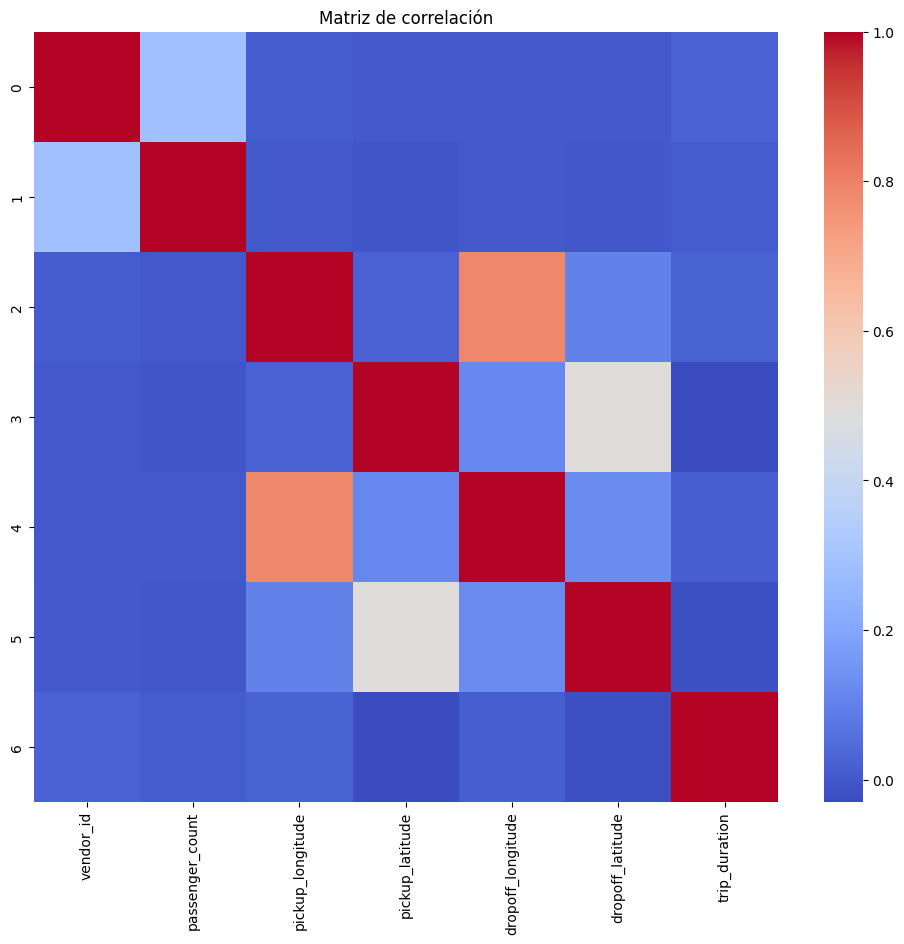

In [ ]:
plt.figure(
    figsize=(12,10)
)

sns.heatmap(
    corr.to_pandas(),
    cmap="coolwarm"
)

plt.title(
    "Matriz de correlación"
)

plt.show()

Outliers:

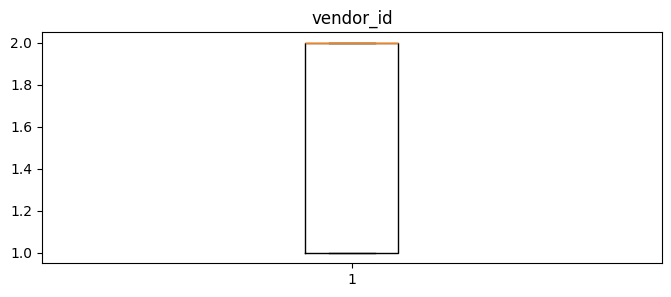

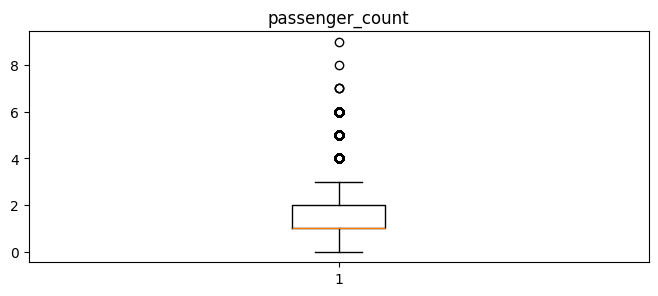

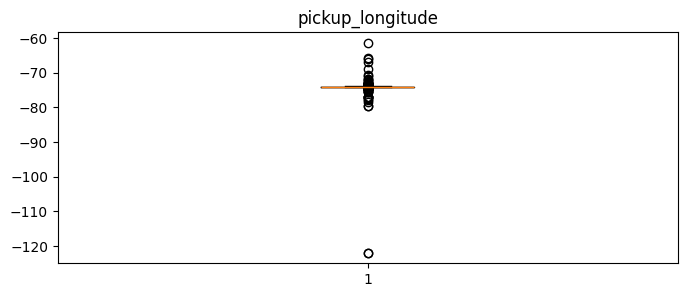

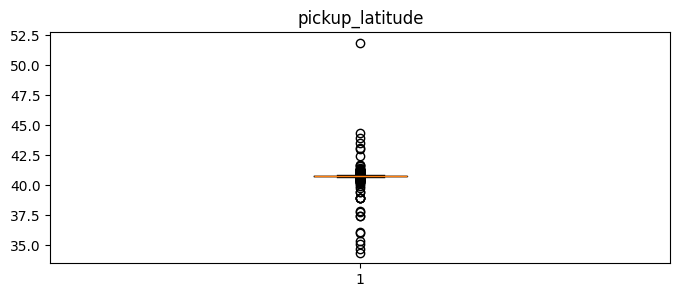

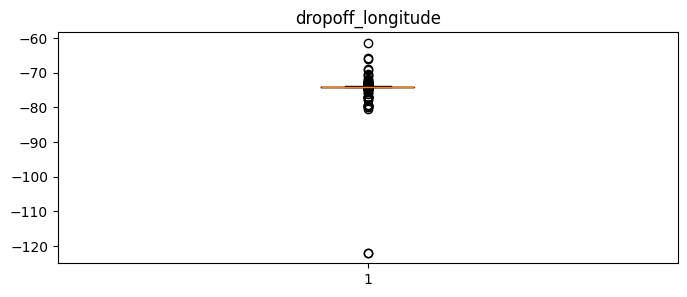

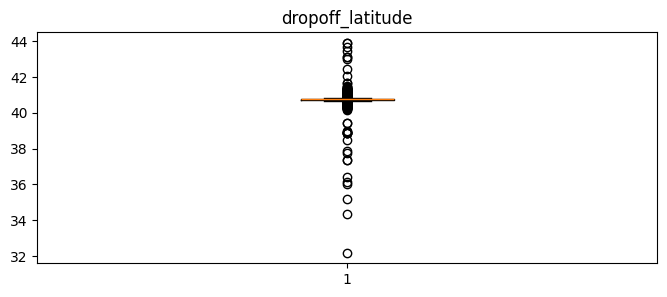

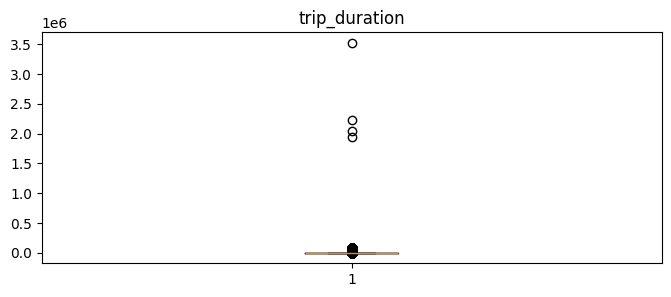

In [ ]:
for col in numeric_cols:

    plt.figure(
        figsize=(8,3)
    )

    plt.boxplot(
        df[col]
    )

    plt.title(
        col
    )

    plt.show()

## Resumen:

In [ ]:
print("Resumen del EDA")

print(
    f"Registros: {df.shape[0]}"
)

print(
    f"Variables: {df.shape[1]}"
)

print(
    f"Variables numéricas: {len(numeric_cols)}"
)

print(
    f"Variables categóricas: {len(categorical)}"
)

print(
    f"Valores faltantes totales: {sum(df.null_count().row(0))}"
)

Resumen del EDA
Registros: 1458644
Variables: 11
Variables numéricas: 7
Variables categóricas: 4
Valores faltantes totales: 0
